EXERCISE A

Top of book = the highest bid and the lowest ask 

Dedupe fully duplicated rows, nothing changed

In [2]:
import polars as pl

df_raw = pl.read_parquet("../parquets/A_hkex_2800_top_of_book.parquet")

df = df_raw.unique().sort("seq_id")

pl.DataFrame({
    "stage": ["raw", "deduped_and_seq_sorted"],
    "rows": [df_raw.height, df.height],
    "columns": [df_raw.width, df.width],
})

stage,rows,columns
str,i64,i64
"""raw""",109544,9
"""deduped_and_seq_sorted""",109544,9


In [3]:
df.group_by("seq_id").len().filter(pl.col("len") > 1)

seq_id,len
i64,u32


In [4]:
for col in ["ingress_ts", "transaction_ts", "publish_ts"]:
    dupes = df.group_by(col).len().filter(pl.col("len") > 1)
    print(col, "duplicate timestamp values:", dupes.height, "rows involved:", dupes["len"].sum())

ingress_ts duplicate timestamp values: 23458 rows involved: 77378
transaction_ts duplicate timestamp values: 8890 rows involved: 23764
publish_ts duplicate timestamp values: 8890 rows involved: 23764


In [5]:
df = df.sort("seq_id").with_columns(
    same_bbo_as_prev=(
        (pl.col("bid_price") == pl.col("bid_price").shift(1))
        & (pl.col("bid_qty") == pl.col("bid_qty").shift(1))
        & (pl.col("ask_price") == pl.col("ask_price").shift(1))
        & (pl.col("ask_qty") == pl.col("ask_qty").shift(1))
    )
)

df.filter(pl.col("same_bbo_as_prev"))

df.select(
    pl.col("same_bbo_as_prev").sum().alias("same_bbo_as_prev_count")
)

same_bbo_as_prev_count
u32
0


In [6]:
df = df.with_columns(repeated_quote=pl.col("ingress_ts") > pl.col("ingress_ts").min().over(["instrument", "transaction_ts", "publish_ts", "bid_price", "bid_qty", "ask_price", "ask_qty"]))
df.group_by(["instrument", "transaction_ts", "publish_ts", "bid_price", "bid_qty", "ask_price", "ask_qty"]).agg(pl.len(), pl.col("ingress_ts").min().alias("first_capture"), pl.col("ingress_ts").max().alias("last_capture")).filter(pl.col("last_capture") > pl.col("first_capture"))

instrument,transaction_ts,publish_ts,bid_price,bid_qty,ask_price,ask_qty,len,first_capture,last_capture
str,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,f64,u32,"datetime[μs, UTC]","datetime[μs, UTC]"
"""S|2800-HKD:SPOT""",2026-08-13 06:26:55.093360 UTC,2026-08-13 06:26:55.093360 UTC,25.94,110.0,25.88,100.0,3,2026-08-13 06:26:55.131411 UTC,2026-08-13 06:35:11.433431 UTC
"""S|2800-HKD:SPOT""",2026-08-13 06:35:54.022180 UTC,2026-08-13 06:35:54.022180 UTC,25.94,110.0,25.86,4.0,11,2026-08-13 06:35:54.056699 UTC,2026-08-13 07:50:11.390074 UTC
"""S|2800-HKD:SPOT""",2026-08-13 03:34:54.473950 UTC,2026-08-13 03:34:54.473950 UTC,26.1,6.0,25.5,5.0,2,2026-08-13 03:34:54.515856 UTC,2026-08-13 03:35:17.794405 UTC
"""S|2800-HKD:SPOT""",2026-08-13 06:19:40.062780 UTC,2026-08-13 06:19:40.062780 UTC,25.94,110.0,26.0,275.0,2,2026-08-13 06:19:40.106708 UTC,2026-08-13 06:20:11.035989 UTC
"""S|2800-HKD:SPOT""",2026-08-13 02:53:19.348140 UTC,2026-08-13 02:53:19.348140 UTC,25.96,3.433e6,25.98,1.3012e7,2,2026-08-13 02:53:19.378167 UTC,2026-08-13 02:53:19.382195 UTC
…,…,…,…,…,…,…,…,…,…
"""S|2800-HKD:SPOT""",2026-08-13 01:39:59.993020 UTC,2026-08-13 01:39:59.993020 UTC,25.8,80.0,26.0,1.0,2,2026-08-13 01:40:00.028535 UTC,2026-08-13 01:44:45.921555 UTC
"""S|2800-HKD:SPOT""",2026-08-13 02:03:20.711420 UTC,2026-08-13 02:03:20.711420 UTC,25.94,50.0,25.92,1.0,5,2026-08-13 02:03:20.746101 UTC,2026-08-13 02:29:38.217551 UTC
"""S|2800-HKD:SPOT""",2026-08-13 04:42:45.582680 UTC,2026-08-13 04:42:45.582680 UTC,25.94,7.7055e6,25.96,541500.0,3,2026-08-13 04:42:45.635762 UTC,2026-08-13 04:54:51.324 UTC


In [7]:
df.sort("seq_id").select(
    pl.col("ingress_ts").is_sorted().alias("ingress_monotonic"),
    pl.col("transaction_ts").is_sorted().alias("transaction_monotonic"),
    pl.col("publish_ts").is_sorted().alias("publish_monotonic"),
)

ingress_monotonic,transaction_monotonic,publish_monotonic
bool,bool,bool
false,false,false


In [8]:
df = df.sort("seq_id").with_columns([(pl.col(c).diff().dt.total_microseconds() < 0).fill_null(False).alias(f"{c}_reversal") for c in ["ingress_ts", "transaction_ts", "publish_ts"]])
df.sort("seq_id").select(pl.col(["ingress_ts", "transaction_ts", "publish_ts"]).diff().dt.total_microseconds()).unpivot(variable_name="clock", value_name="step_us").group_by("clock").agg((pl.col("step_us") < 0).sum().alias("reversals"), pl.col("step_us").filter(pl.col("step_us") < 0).min().abs().fill_null(0).alias("max_reversal_us"))

clock,reversals,max_reversal_us
str,u32,i64
"""transaction_ts""",55,5333258300
"""publish_ts""",55,5333258300
"""ingress_ts""",22,5


In [9]:
df.filter(
    (pl.col("bid_price") <= 0)
    | (pl.col("ask_price") <= 0)
    | (pl.col("bid_qty") <= 0)
    | (pl.col("ask_qty") <= 0)
)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,same_bbo_as_prev,repeated_quote,ingress_ts_reversal,transaction_ts_reversal,publish_ts_reversal
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool,bool,bool,bool,bool


Negative number check, pass\
Timestamp sanity, pass

In [10]:
df.filter(
    (pl.col("ingress_ts") < pl.col("publish_ts"))
    | (pl.col("publish_ts") < pl.col("transaction_ts"))
)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,same_bbo_as_prev,repeated_quote,ingress_ts_reversal,transaction_ts_reversal,publish_ts_reversal
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool,bool,bool,bool,bool


In [11]:
df_latency = df.with_columns(
    capture_latency_us = (
        pl.col("ingress_ts") - pl.col("publish_ts")
    ).dt.total_microseconds()
)

df_latency.filter(pl.col("capture_latency_us") > 1_000_000)

df_latency.select(
    pl.col("capture_latency_us").min().alias("min"),
    pl.col("capture_latency_us").quantile(0.5).alias("median"),
    pl.col("capture_latency_us").quantile(0.95).alias("p95"),
    pl.col("capture_latency_us").quantile(0.99).alias("p99"),
    pl.col("capture_latency_us").max().alias("max"),
)

min,median,p95,p99,max
i64,f64,f64,f64,i64
28001,33081.0,40216.0,51337.0,5333363136


In [12]:
latency_us = (pl.col("ingress_ts") - pl.col("publish_ts")).dt.total_microseconds()

p95_latency_us = df.select(latency_us.quantile(0.95)).item()
p99_latency_us = df.select(latency_us.quantile(0.99)).item()

df = df.with_columns(
    capture_latency_us=latency_us,
    latency_gt_p95=latency_us > p95_latency_us,
    latency_gt_p99=latency_us > p99_latency_us,
    latency_gt_1s=latency_us > 1_000_000,
)

In [13]:
df.select(pl.col("latency_gt_1s").sum().alias("delayed_quotes"), (pl.col("latency_gt_1s") & pl.col("repeated_quote")).sum().alias("delayed_repeated_quotes"))

delayed_quotes,delayed_repeated_quotes
u32,u32
59,58


In [14]:
df = df.with_columns(
    missing_bid=pl.col("bid_price").is_null() | pl.col("bid_qty").is_null(),
    missing_ask=pl.col("ask_price").is_null() | pl.col("ask_qty").is_null(),
).with_columns(
    quote_state=
        pl.when(pl.col("missing_bid") & pl.col("missing_ask")).then(pl.lit("no_bbo"))
        .when(pl.col("missing_bid")).then(pl.lit("ask_only"))
        .when(pl.col("missing_ask")).then(pl.lit("bid_only"))
        .otherwise(pl.lit("two_sided"))
)

df.group_by("quote_state").len()

quote_state,len
str,u32
"""bid_only""",2
"""two_sided""",109541
"""ask_only""",1


In [15]:
df = df.with_columns(
    spread=pl.col("ask_price") - pl.col("bid_price"),
    crossed_book=pl.col("bid_price") > pl.col("ask_price"),
    locked_book=pl.col("bid_price") == pl.col("ask_price"),
)

df.select(
    pl.col("crossed_book").sum().alias("crossed_book_count"),
    pl.col("locked_book").sum().alias("locked_book_count"),
)

crossed_book_count,locked_book_count
u32,u32
71,112


In [16]:
df = df.with_columns(
    mid=(pl.col("bid_price") + pl.col("ask_price")) / 2
)

df = df.with_columns(
    spread_pct=pl.col("spread") / pl.col("mid") * 100
)

p99_spread_pct = df.select(pl.col("spread_pct").quantile(0.99)).item()

df = df.with_columns(
    spread_outlier=pl.col("spread_pct") > p99_spread_pct
)

df = df.with_columns(spread_outlier=pl.col("spread_pct") > pl.col("spread_pct").quantile(0.99))

df.select(
    pl.col("spread_outlier").sum().alias("spread_outlier_count"),
    pl.col("spread_pct").quantile(0.99).alias("p99_spread_pct"),
    pl.col("spread_pct").max().alias("max_spread_pct"),
)

spread_outlier_count,p99_spread_pct,max_spread_pct
u32,f64,f64
812,0.15444,6.422018


In [17]:
df_moves = df.filter(~pl.col("repeated_quote")).sort(["publish_ts", "seq_id"]).with_columns(
    bid_change_pct=(pl.col("bid_price") / pl.col("bid_price").shift(1) - 1).abs() * 100,
    ask_change_pct=(pl.col("ask_price") / pl.col("ask_price").shift(1) - 1).abs() * 100,
)

df_moves.sort(pl.max_horizontal("bid_change_pct", "ask_change_pct"), descending=True, nulls_last=True).select("publish_ts", "seq_id", "bid_price", "ask_price", "bid_qty", "ask_qty", "bid_change_pct", "ask_change_pct").head(10)

publish_ts,seq_id,bid_price,ask_price,bid_qty,ask_qty,bid_change_pct,ask_change_pct
"datetime[μs, UTC]",i64,f64,f64,f64,f64,f64,f64
2026-08-13 03:36:37.301010 UTC,95073599,25.92,25.94,1.96185e7,5.565e6,0.689655,8.083333
2026-08-13 03:36:36.099430 UTC,95072669,26.1,24.0,6.0,5.0,0.694444,7.478797
2026-08-13 01:30:05.442630 UTC,60126655,25.78,25.8,370000.0,1.2125e6,3.951613,0.769231
2026-08-13 01:30:04.482440 UTC,60117857,24.8,26.0,25.0,1.0,3.801396,0.775194
2026-08-13 01:49:24.085310 UTC,71182348,25.92,25.94,1.8415e6,1.07505e7,1.25,3.76
2026-08-13 01:49:52.244690 UTC,71418984,25.92,25.94,1.38e6,1.04085e7,0.232019,3.76
2026-08-13 01:57:38.460050 UTC,74783346,25.92,25.94,1.2246e7,1.08175e7,0.077101,3.76
2026-08-13 01:54:31.619500 UTC,73410614,25.9,25.92,1.1054e7,9.593e6,1.171875,3.68
2026-08-13 01:54:39.840230 UTC,73459668,25.9,25.92,1.11555e7,1.429e6,0.07728,3.68


In [18]:
i = df_moves.select(pl.max_horizontal("bid_change_pct", "ask_change_pct").arg_max()).item()
df_moves.slice(max(i - 2, 0), 5).select("publish_ts", "seq_id", "bid_price", "ask_price", "bid_qty", "ask_qty")

publish_ts,seq_id,bid_price,ask_price,bid_qty,ask_qty
"datetime[μs, UTC]",i64,f64,f64,f64,f64
2026-08-13 03:36:35.905310 UTC,95072399,25.92,25.94,1.96185e7,5.7625e6
2026-08-13 03:36:36.099430 UTC,95072669,26.1,24.0,6.0,5.0
2026-08-13 03:36:37.301010 UTC,95073599,25.92,25.94,1.96185e7,5.565e6
2026-08-13 03:36:37.548630 UTC,95074107,25.92,25.94,1.96185e7,5.165e6
2026-08-13 03:36:37.695560 UTC,95074221,25.92,25.94,1.96185e7,5.3645e6


In [19]:
df_moves = df.filter((pl.col("quote_state") == "two_sided") & ~pl.any_horizontal("repeated_quote", "crossed_book", "locked_book", "spread_outlier", "latency_gt_p99", "latency_gt_1s")).sort(["publish_ts", "seq_id"]).with_columns(
    bid_change_pct=(pl.col("bid_price") / pl.col("bid_price").shift(1) - 1).abs() * 100,
    ask_change_pct=(pl.col("ask_price") / pl.col("ask_price").shift(1) - 1).abs() * 100,
)

i = df_moves.select(pl.max_horizontal("bid_change_pct", "ask_change_pct").arg_max()).item()
df_moves.slice(max(i - 2, 0), 5).select("publish_ts", "seq_id", "bid_price", "ask_price", "bid_qty", "ask_qty")

publish_ts,seq_id,bid_price,ask_price,bid_qty,ask_qty
"datetime[μs, UTC]",i64,f64,f64,f64,f64
2026-08-13 06:08:21.982030 UTC,109023774,25.92,25.94,2.05585e7,1.2125e7
2026-08-13 06:08:21.988340 UTC,109024016,25.92,25.94,2.05585e7,1.2175e7
2026-08-13 06:08:22.628300 UTC,109025452,25.96,26.0,80.0,275.0
2026-08-13 06:08:22.791440 UTC,109025754,25.92,25.94,2.05585e7,1.2125e7
2026-08-13 06:08:22.865310 UTC,109026382,25.92,25.94,2.05585e7,1.2175e7


In [20]:
df = df.with_columns(transient_quote_candidate=pl.col("seq_id") == 109025452)

In [21]:
df.sort("seq_id").with_columns(
    time_gap_s=(pl.col("publish_ts") - pl.col("publish_ts").shift(1)).dt.total_seconds()
).select(
    pl.col("time_gap_s").min().alias("min_gap_s"),
    pl.col("time_gap_s").quantile(0.95).alias("p95_gap_s"),
    pl.col("time_gap_s").quantile(0.99).alias("p99_gap_s"),
    pl.col("time_gap_s").max().alias("max_gap_s"),
)

min_gap_s,p95_gap_s,p99_gap_s,max_gap_s
i64,f64,f64,i64
-5333,0.0,3.0,5333


In [22]:
df = df.sort("seq_id").with_columns(
    time_gap_s=(pl.col("publish_ts") - pl.col("publish_ts").shift(1)).dt.total_seconds()
).with_columns(
    large_time_gap=pl.col("time_gap_s").abs() > 60
)

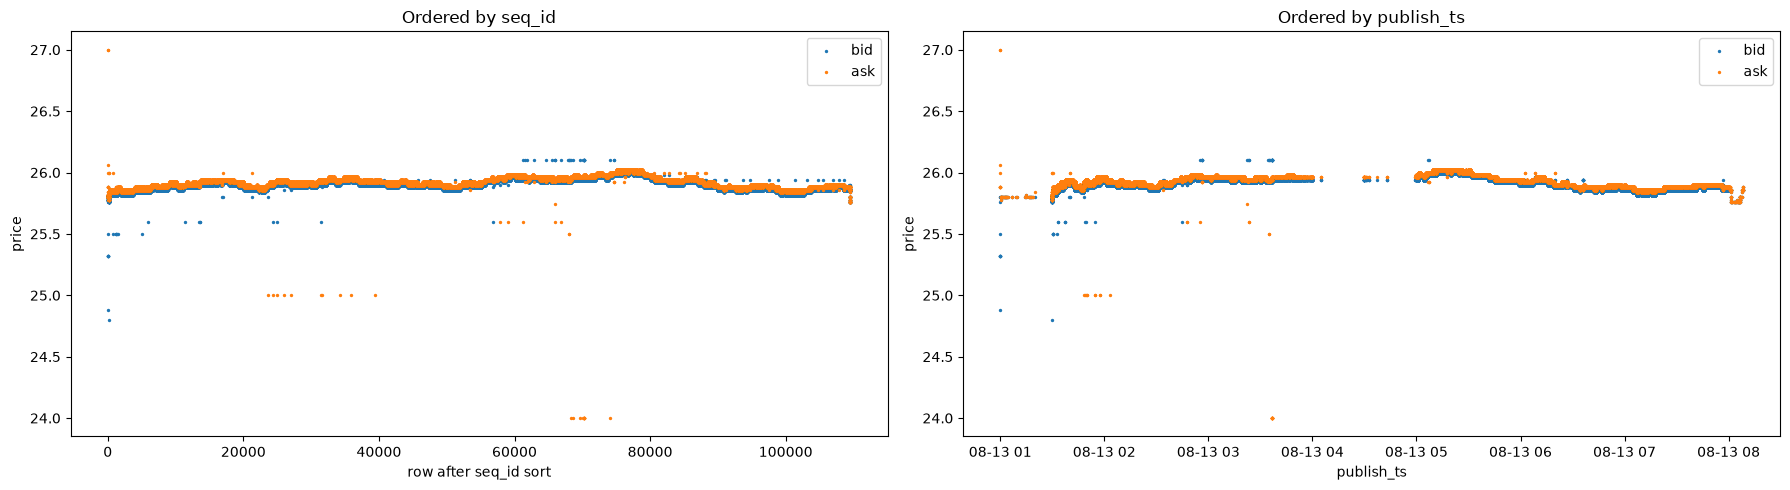

In [23]:
import matplotlib.pyplot as plt

df_seq = df.sort("seq_id").with_row_index("row")
df_time = df.sort(["publish_ts", "seq_id"])

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].scatter(df_seq["row"], df_seq["bid_price"], s=2, label="bid")
ax[0].scatter(df_seq["row"], df_seq["ask_price"], s=2, label="ask")
ax[0].set_title("Ordered by seq_id")
ax[0].set_xlabel("row after seq_id sort")
ax[0].set_ylabel("price")
ax[0].legend()

ax[1].scatter(df_time["publish_ts"], df_time["bid_price"], s=2, label="bid")
ax[1].scatter(df_time["publish_ts"], df_time["ask_price"], s=2, label="ask")
ax[1].set_title("Ordered by publish_ts")
ax[1].set_xlabel("publish_ts")
ax[1].set_ylabel("price")
ax[1].legend()

plt.tight_layout()
plt.show()

In [24]:
df = df.drop("session_phase", strict=False).with_columns(
    minute_of_day=pl.col("publish_ts").dt.hour() * 60 + pl.col("publish_ts").dt.minute()
).with_columns(
    session_phase=
        pl.when(pl.col("minute_of_day") < 60).then(pl.lit("before_open"))
        .when(pl.col("minute_of_day") < 90).then(pl.lit("pre_open"))
        .when(pl.col("minute_of_day") < 240).then(pl.lit("morning_continuous"))
        .when(pl.col("minute_of_day") < 300).then(pl.lit("lunch_break"))
        .when(pl.col("minute_of_day") < 480).then(pl.lit("afternoon_continuous"))
        .when(pl.col("minute_of_day") <= 490).then(pl.lit("closing_auction"))
        .otherwise(pl.lit("after_close"))
)

In [25]:
df.group_by("session_phase").agg(
    pl.col("publish_ts").min().alias("min_publish_ts"),
    pl.col("publish_ts").max().alias("max_publish_ts"),
    pl.len().alias("rows"),
).sort("min_publish_ts")

session_phase,min_publish_ts,max_publish_ts,rows
str,"datetime[μs, UTC]","datetime[μs, UTC]",u32
"""pre_open""",2026-08-13 01:00:00.082890 UTC,2026-08-13 05:45:58.216380 UTC,5116
"""morning_continuous""",2026-08-13 01:30:00.002550 UTC,2026-08-13 06:23:59.594660 UTC,49392
"""before_open""",2026-08-13 02:08:00.024120 UTC,2026-08-13 08:08:12.709010 UTC,55036


In [26]:
minute_of_day = (
    pl.col("publish_ts").dt.hour().cast(pl.Int32) * 60
    + pl.col("publish_ts").dt.minute().cast(pl.Int32)
)

df = df.drop(["session_phase", "minute_of_day"], strict=False).with_columns(
    minute_of_day=minute_of_day
).with_columns(
    session_phase=
        pl.when(pl.col("minute_of_day") < 60).then(pl.lit("before_open"))
        .when(pl.col("minute_of_day") < 90).then(pl.lit("pre_open"))
        .when(pl.col("minute_of_day") < 240).then(pl.lit("morning_continuous"))
        .when(pl.col("minute_of_day") < 300).then(pl.lit("lunch_break"))
        .when(pl.col("minute_of_day") < 480).then(pl.lit("afternoon_continuous"))
        .when(pl.col("minute_of_day") <= 490).then(pl.lit("closing_auction"))
        .otherwise(pl.lit("after_close"))
)

In [27]:
df.group_by("session_phase").agg(
    pl.col("minute_of_day").min().alias("min_minute"),
    pl.col("minute_of_day").max().alias("max_minute"),
    pl.col("publish_ts").min().alias("min_publish_ts"),
    pl.col("publish_ts").max().alias("max_publish_ts"),
    pl.len().alias("rows"),
).sort("min_minute")

session_phase,min_minute,max_minute,min_publish_ts,max_publish_ts,rows
str,i32,i32,"datetime[μs, UTC]","datetime[μs, UTC]",u32
"""pre_open""",60,80,2026-08-13 01:00:00.082890 UTC,2026-08-13 01:20:03.782040 UTC,50
"""morning_continuous""",90,239,2026-08-13 01:30:00.002550 UTC,2026-08-13 03:59:59.494730 UTC,70157
"""lunch_break""",245,299,2026-08-13 04:05:00.007010 UTC,2026-08-13 04:59:01.204940 UTC,36
"""afternoon_continuous""",300,479,2026-08-13 05:00:00.002430 UTC,2026-08-13 07:59:59.991970 UTC,39219
"""closing_auction""",481,488,2026-08-13 08:01:00.013880 UTC,2026-08-13 08:08:12.709010 UTC,82


In [28]:
df.filter(
    pl.col("session_phase").is_in(["morning_continuous", "afternoon_continuous"])
).select(
    pl.col("capture_latency_us").min().alias("min_us"),
    pl.col("capture_latency_us").quantile(0.50).alias("p50_us"),
    pl.col("capture_latency_us").quantile(0.95).alias("p95_us"),
    pl.col("capture_latency_us").quantile(0.99).alias("p99_us"),
    pl.col("capture_latency_us").max().alias("max_us"),
)

min_us,p50_us,p95_us,p99_us,max_us
i64,f64,f64,f64,i64
28001,33079.0,40171.0,50585.0,5333363136


In [29]:
df.select(
    pl.len().alias("rows"),
    pl.col("same_bbo_as_prev").sum().alias("same_bbo_as_prev"),
    pl.col("latency_gt_p95").sum().alias("latency_gt_p95"),
    pl.col("latency_gt_p99").sum().alias("latency_gt_p99"),
    pl.col("latency_gt_1s").sum().alias("latency_gt_1s"),
    (pl.col("quote_state") != "two_sided").sum().alias("incomplete_bbo"),
    pl.col("crossed_book").sum().alias("crossed_book"),
    pl.col("locked_book").sum().alias("locked_book"),
    pl.col("spread_outlier").sum().alias("spread_outlier"),
    pl.col("large_time_gap").sum().alias("large_time_gap"),
)

rows,same_bbo_as_prev,latency_gt_p95,latency_gt_p99,latency_gt_1s,incomplete_bbo,crossed_book,locked_book,spread_outlier,large_time_gap
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
109544,0,5475,1095,59,3,71,112,812,107


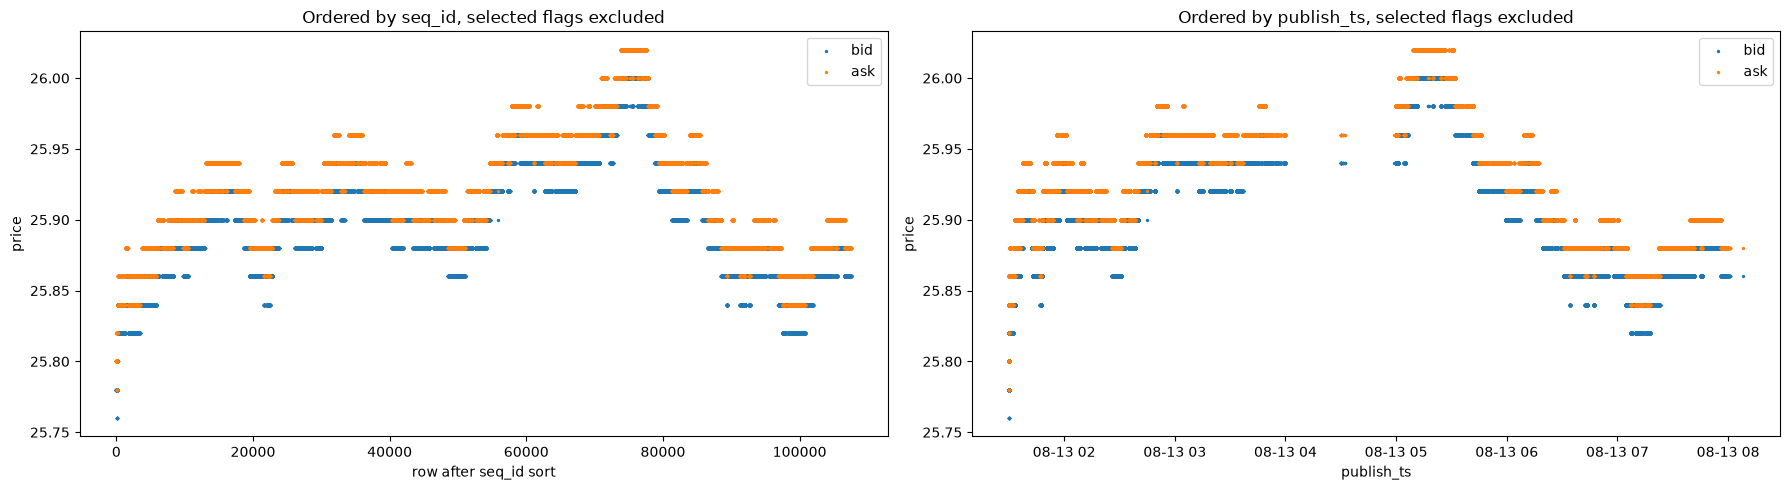

In [30]:
df_plot = df.filter(
    (pl.col("quote_state") == "two_sided")
    & (~pl.col("crossed_book"))
    & (~pl.col("locked_book"))
    & (~pl.col("spread_outlier"))
    & (~pl.col("latency_gt_p99"))
    & (~pl.col("latency_gt_1s"))
    & (~pl.col("large_time_gap"))
    & (~pl.col("repeated_quote"))
    & (~pl.col("transient_quote_candidate"))
)

df_seq = df_plot.sort("seq_id").with_row_index("row")
df_time = df_plot.sort(["publish_ts", "seq_id"])

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].scatter(df_seq["row"], df_seq["bid_price"], s=2, label="bid")
ax[0].scatter(df_seq["row"], df_seq["ask_price"], s=2, label="ask")
ax[0].set_title("Ordered by seq_id, selected flags excluded")
ax[0].set_xlabel("row after seq_id sort")
ax[0].set_ylabel("price")
ax[0].legend()

ax[1].scatter(df_time["publish_ts"], df_time["bid_price"], s=2, label="bid")
ax[1].scatter(df_time["publish_ts"], df_time["ask_price"], s=2, label="ask")
ax[1].set_title("Ordered by publish_ts, selected flags excluded")
ax[1].set_xlabel("publish_ts")
ax[1].set_ylabel("price")
ax[1].legend()

plt.tight_layout()
plt.show()

very tight range. looks better

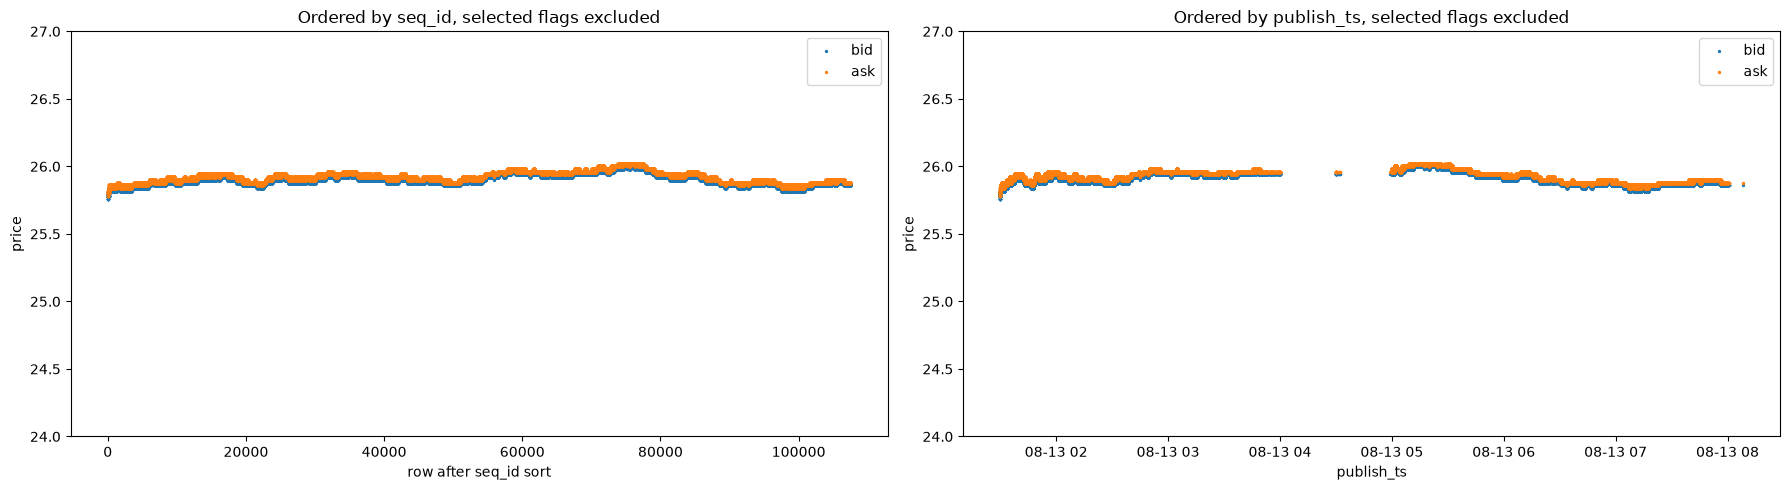

In [31]:
df_plot = df.filter(
    (pl.col("quote_state") == "two_sided")
    & (~pl.col("crossed_book"))
    & (~pl.col("locked_book"))
    & (~pl.col("spread_outlier"))
    & (~pl.col("latency_gt_p99"))
    & (~pl.col("latency_gt_1s"))
    & (~pl.col("large_time_gap"))
    & (~pl.col("repeated_quote"))
    & (~pl.col("transient_quote_candidate"))
)

df_seq = df_plot.sort("seq_id").with_row_index("row")
df_time = df_plot.sort(["publish_ts", "seq_id"])

fig, ax = plt.subplots(1, 2, figsize=(18, 5))

ax[0].scatter(df_seq["row"], df_seq["bid_price"], s=2, label="bid")
ax[0].scatter(df_seq["row"], df_seq["ask_price"], s=2, label="ask")
ax[0].set_title("Ordered by seq_id, selected flags excluded")
ax[0].set_xlabel("row after seq_id sort")
ax[0].set_ylabel("price")
ax[0].set_ylim(24, 27)
ax[0].legend()

ax[1].scatter(df_time["publish_ts"], df_time["bid_price"], s=2, label="bid")
ax[1].scatter(df_time["publish_ts"], df_time["ask_price"], s=2, label="ask")
ax[1].set_title("Ordered by publish_ts, selected flags excluded")
ax[1].set_xlabel("publish_ts")
ax[1].set_ylabel("price")
ax[1].set_ylim(24, 27)
ax[1].legend()

plt.tight_layout()
plt.show()

In [32]:
df_plot.sort(["publish_ts", "seq_id"]).with_columns(
    mid=(pl.col("bid_price") + pl.col("ask_price")) / 2
).with_columns(
    mid_change_pct=(pl.col("mid") / pl.col("mid").shift(1) - 1).abs() * 100
).sort("mid_change_pct", descending=True, nulls_last=True).head(10)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,same_bbo_as_prev,repeated_quote,ingress_ts_reversal,transaction_ts_reversal,publish_ts_reversal,capture_latency_us,latency_gt_p95,latency_gt_p99,latency_gt_1s,missing_bid,missing_ask,quote_state,spread,crossed_book,locked_book,mid,spread_pct,spread_outlier,transient_quote_candidate,time_gap_s,large_time_gap,minute_of_day,session_phase,mid_change_pct
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool,bool,bool,bool,bool,i64,bool,bool,bool,bool,bool,str,f64,bool,bool,f64,f64,bool,bool,i64,bool,i32,str,f64
"""S|2800-HKD:SPOT""",2026-08-13 01:30:02.273398 UTC,2026-08-13 01:30:02.242940 UTC,2026-08-13 01:30:02.242940 UTC,60094652,25.78,184500.0,25.8,915500.0,false,false,false,false,false,30458,false,false,false,false,false,"""two_sided""",0.02,false,false,25.79,0.077549,false,false,0,false,90,"""morning_continuous""",0.07761
"""S|2800-HKD:SPOT""",2026-08-13 01:30:00.291277 UTC,2026-08-13 01:30:00.253470 UTC,2026-08-13 01:30:00.253470 UTC,60067851,25.8,126000.0,25.82,624000.0,false,false,false,false,false,37807,false,false,false,false,false,"""two_sided""",0.02,false,false,25.81,0.077489,false,false,0,false,90,"""morning_continuous""",0.077549
"""S|2800-HKD:SPOT""",2026-08-13 01:30:06.763549 UTC,2026-08-13 01:30:06.732390 UTC,2026-08-13 01:30:06.732390 UTC,60139525,25.8,164000.0,25.82,1.3415e6,false,false,false,false,false,31159,false,false,false,false,false,"""two_sided""",0.02,false,false,25.81,0.077489,false,false,0,false,90,"""morning_continuous""",0.077549
"""S|2800-HKD:SPOT""",2026-08-13 01:30:01.816806 UTC,2026-08-13 01:30:01.783720 UTC,2026-08-13 01:30:01.783720 UTC,60086364,25.76,989000.0,25.78,156000.0,false,false,false,false,false,33086,false,false,false,false,false,"""two_sided""",0.02,false,false,25.77,0.07761,false,false,0,false,90,"""morning_continuous""",0.077549
"""S|2800-HKD:SPOT""",2026-08-13 01:30:00.041569 UTC,2026-08-13 01:30:00.007430 UTC,2026-08-13 01:30:00.007430 UTC,60059740,25.78,11000.0,25.8,500000.0,false,false,false,false,false,34139,false,false,false,false,false,"""two_sided""",0.02,false,false,25.79,0.077549,false,false,0,false,90,"""morning_continuous""",0.077489
"""S|2800-HKD:SPOT""",2026-08-13 01:30:01.284127 UTC,2026-08-13 01:30:01.254680 UTC,2026-08-13 01:30:01.254680 UTC,60081389,25.78,662000.0,25.8,53000.0,false,false,false,false,false,29447,false,false,false,false,false,"""two_sided""",0.02,false,false,25.79,0.077549,false,false,0,false,90,"""morning_continuous""",0.077489
"""S|2800-HKD:SPOT""",2026-08-13 01:30:07.789131 UTC,2026-08-13 01:30:07.756180 UTC,2026-08-13 01:30:07.756180 UTC,60149820,25.82,159000.0,25.84,1.0195e6,false,false,false,false,false,32951,false,false,false,false,false,"""two_sided""",0.02,false,false,25.83,0.077429,false,false,0,false,90,"""morning_continuous""",0.077489
"""S|2800-HKD:SPOT""",2026-08-13 01:30:09.141345 UTC,2026-08-13 01:30:09.112550 UTC,2026-08-13 01:30:09.112550 UTC,60163807,25.84,14000.0,25.86,1.008e6,false,false,false,false,false,28795,false,false,false,false,false,"""two_sided""",0.02,false,false,25.85,0.077369,false,false,0,false,90,"""morning_continuous""",0.077429
"""S|2800-HKD:SPOT""",2026-08-13 01:30:10.263364 UTC,2026-08-13 01:30:10.232400 UTC,2026-08-13 01:30:10.232400 UTC,60174898,25.84,155000.0,25.86,3.006e6,false,false,false,false,false,30964,false,false,false,false,false,"""two_sided""",0.02,false,false,25.85,0.077369,false,false,0,false,90,"""morning_continuous""",0.077429


In [33]:
df.write_parquet("../parquets/A_topofbook_flagged.parquet")